Checking computed $obsCCF$ and getting $CN_{t}$

In [22]:
import os
import pandas as pd, numpy as np

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

In [274]:
PARQUET_VALIDATION_CCF = "/Users/wuchh/Downloads/CRUK0810.PhyloCCF.parquet"

PARQUET_MUTCPN = "/Users/wuchh/Downloads/CRUK0810.mutCpnNum.parquet"
PARQUET_VAF = "/Users/wuchh/Downloads/CRUK0810.varAlleleFreqs.parquet"
PARQUET_MAJOR_CPN = "/Users/wuchh/Downloads/CRUK0810.nAraw.parquet"
PARQUET_MINOR_CPN = "/Users/wuchh/Downloads/CRUK0810.nBraw.parquet"

PARQUET_VAR_READS = "/Users/wuchh/Downloads/CRUK0810.variantReads.parquet"
PARQUET_TOT_READS = "/Users/wuchh/Downloads/CRUK0810.totalReads.parquet"

PURITY_TSV = "/Users/wuchh/Downloads/metsFigures/data/20220808_purityandploidy.txt"

SUFFIXES = {
    "PhyloCCF": "_PhyloCCF",
    "mutCpnNum": "_mut.cpn.num",
    "varAlleleFreqs": "_VAF",
    "nAraw": "_nAraw",
    "nBraw": "_nBraw",
    "variantReads": "_var_count",
    "totalReads": "_cov"
}

In [275]:
sample_purities = pd.read_csv(PURITY_TSV, sep='\t')\
                    .set_index("Sample")["final.purity"]\
                    .to_dict()

In [277]:
def read_parquet(file, index_colname="mutation_id"):

    def _get_suffix(file):
        _, suffix = os.path.basename(file)\
                      .rstrip(".parquet")\
                      .split(".")
        return suffix
    
    fs = _get_suffix(file)

    df = pd.read_parquet(file).set_index("mutation_id")
    df.columns = [col.rstrip(SUFFIXES[fs]) for col in df.columns]

    return df

df_vaf, df_major_cpn, df_minor_cpn = map(
    lambda f: read_parquet(f), 
    [PARQUET_VAF, PARQUET_MAJOR_CPN, PARQUET_MINOR_CPN]
)

df_var_counts, df_tot_counts = map(
    lambda f: read_parquet(f), 
    [PARQUET_VAR_READS, PARQUET_TOT_READS]
)

In [53]:
df_total_cpn = df_major_cpn + df_minor_cpn

In [83]:
u = []
for row in df_vaf.index:
    chrom, pos = row.split(':', maxsplit=3)[1:3]
    u.append((chrom, pos))

mutational_loci = pd.DataFrame(u, columns=["CHROM", "POS"])

In [84]:
mutational_loci

,CHROM,POS
0,1,2704319
1,1,18434754
2,1,19501462
3,1,20141398
4,1,23707913
...,...,...
513,22,23401525
514,22,35661321
515,22,37420730
516,22,37966167


In [329]:
df_total_cpn.shape

(518, 13)

In [85]:
df_total_cpn

,CRUK0810_SU_LN1,CRUK0810_SU_LN2,CRUK0810_SU_LN3,CRUK0810_SU_T1.R1,CRUK0810_SU_T1.R2,CRUK0810_SU_T1.R3,CRUK0810_SU_T1.R4,CRUK0810_SU_T1.R5,CRUK0810_SU_T1.R6,CRUK0810_SU_T1.R7,CRUK0810_SU_T1.R8,CRUK0810_SU_FLN1,CRUK0810_BR_LN1
mutation_id,,,,,,,,,,,,,
CRUK0810:1:2704319:C:T,2,2,2,2,2,2,2,2,2,2,2,2,2
CRUK0810:1:18434754:G:T,2,2,2,2,2,2,2,2,2,2,2,2,2
CRUK0810:1:19501462:G:A,2,2,2,2,2,2,2,2,2,2,2,2,2
CRUK0810:1:20141398:C:A,2,2,2,2,2,2,2,2,2,2,2,2,2
CRUK0810:1:23707913:G:A,2,2,2,2,2,2,2,2,2,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
CRUK0810:22:23401525:C:A,3,3,3,3,3,3,3,3,3,3,3,3,3
CRUK0810:22:35661321:C:T,3,3,3,3,3,3,3,3,3,3,3,3,3
CRUK0810:22:37420730:C:T,3,3,3,3,3,3,3,3,3,3,3,3,3


/var/folders/_k/0wd_frsd3dg1x487y924q979_83jn9/T/ipykernel_6598/2137557761.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 1])


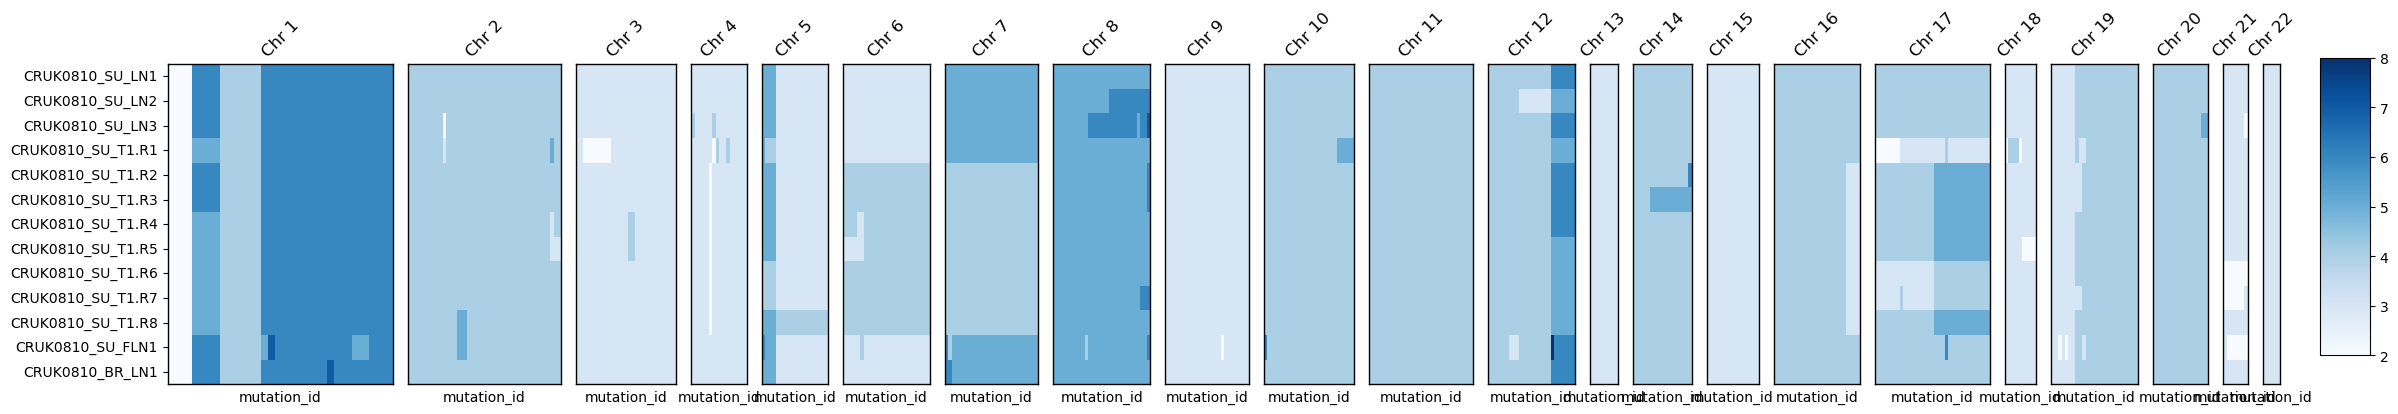

In [182]:
df = df_total_cpn
groups = mutational_loci["CHROM"].tolist()
split_dfs = [group for _, group in df.groupby(groups, sort=False)]
vmin = df.min().min()
vmax = df.max().max()
width_ratios = [len(sub_df) for sub_df in split_dfs]

fig, axes = plt.subplots(1, len(split_dfs), figsize=(25, 4.25),
                         gridspec_kw={'width_ratios': width_ratios})

if len(split_dfs) == 1:
    axes = [axes]

for i, (ax, sub_df) in enumerate(zip(axes, split_dfs)):
    sns.heatmap(sub_df.T, ax=ax, cmap='Blues',
                vmin=vmin, vmax=vmax,
                cbar=False,
                yticklabels=(i == 0),
                xticklabels=False,
                linewidths=0,
                linecolor='none')
    ax.set_title(f'Chr {i+1}', rotation=45, ha='center')
    if i == 0:
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.)
        spine.set_visible(True)

fig.subplots_adjust(right=0.92)
cbar_ax = fig.add_axes([0.93, 0.15, 0.02, 0.7])
sm = plt.cm.ScalarMappable(cmap='Blues', norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax)

plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.show()

In [97]:
p = np.array([sample_purities[col] for col in df_total_cpn.columns])

In [330]:
p

array([0.31, 0.58, 0.13, 0.25, 0.4 , 0.36, 0.49, 0.51, 0.39, 0.44, 0.2 ,
       0.43, 0.26])

In [108]:
df_vaf

,CRUK0810_SU_LN1,CRUK0810_SU_LN2,CRUK0810_SU_LN3,CRUK0810_SU_T1.R1,CRUK0810_SU_T1.R2,CRUK0810_SU_T1.R3,CRUK0810_SU_T1.R4,CRUK0810_SU_T1.R5,CRUK0810_SU_T1.R6,CRUK0810_SU_T1.R7,CRUK0810_SU_T1.R8,CRUK0810_SU_FLN1,CRUK0810_BR_LN1
mutation_id,,,,,,,,,,,,,
CRUK0810:1:2704319:C:T,0.000000,0.000000,0.000000,0.134752,0.173913,0.157895,0.211538,0.207547,0.216418,0.180952,0.093333,0.000000,0.000000
CRUK0810:1:18434754:G:T,0.067797,0.355556,0.037736,0.115385,0.217391,0.151515,0.326923,0.365385,0.166667,0.097561,0.150943,0.300000,0.270833
CRUK0810:1:19501462:G:A,0.000000,0.000000,0.000000,0.000000,0.159574,0.183544,0.252033,0.255474,0.181818,0.223404,0.103774,0.005236,0.000000
CRUK0810:1:20141398:C:A,0.114441,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
CRUK0810:1:23707913:G:A,0.025000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
CRUK0810:22:23401525:C:A,0.261194,0.439024,0.142857,0.107527,0.137681,0.202381,0.157303,0.214286,0.187050,0.206612,0.094595,0.303030,0.224490
CRUK0810:22:35661321:C:T,0.001894,0.002049,0.000000,0.002123,0.155319,0.162602,0.169082,0.165501,0.153333,0.162698,0.111722,0.003571,0.000000
CRUK0810:22:37420730:C:T,0.112514,0.192098,0.071207,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001252,0.179688,0.118280


In [143]:
samples = df_total_cpn.columns

for index in df_total_cpn.index:
    z = df_total_cpn.loc[index, samples]
    
    if not (((z * p) + (2 * (1 - p))) == 2).all():
        break

In [144]:
((z * p) + (2 * (1 - p)))

CRUK0810_SU_LN1      3.24
CRUK0810_SU_LN2      4.32
CRUK0810_SU_LN3      2.52
CRUK0810_SU_T1.R1    2.75
CRUK0810_SU_T1.R2    3.60
CRUK0810_SU_T1.R3    3.44
CRUK0810_SU_T1.R4    3.47
CRUK0810_SU_T1.R5    3.53
CRUK0810_SU_T1.R6    3.17
CRUK0810_SU_T1.R7    3.32
CRUK0810_SU_T1.R8    2.60
CRUK0810_SU_FLN1     3.72
CRUK0810_BR_LN1      3.04
Name: CRUK0810:1:32661445:G:A, dtype: float64

In [145]:
p

array([0.31, 0.58, 0.13, 0.25, 0.4 , 0.36, 0.49, 0.51, 0.39, 0.44, 0.2 ,
       0.43, 0.26])

In [183]:
df_vaf.loc[index, samples] * (2/p)

CRUK0810_SU_LN1      0.000000
CRUK0810_SU_LN2      0.000000
CRUK0810_SU_LN3      0.000000
CRUK0810_SU_T1.R1    0.000000
CRUK0810_SU_T1.R2    0.494071
CRUK0810_SU_T1.R3    0.586420
CRUK0810_SU_T1.R4    0.540729
CRUK0810_SU_T1.R5    0.635439
CRUK0810_SU_T1.R6    0.626346
CRUK0810_SU_T1.R7    0.519481
CRUK0810_SU_T1.R8    0.863636
CRUK0810_SU_FLN1     0.000000
CRUK0810_BR_LN1      0.000000
Name: CRUK0810:1:32661445:G:A, dtype: float64

In [157]:
(df_vaf.loc[index, samples]/p) * ((z * p) + (2 * (1 - p)))

CRUK0810_SU_LN1      0.000000
CRUK0810_SU_LN2      0.000000
CRUK0810_SU_LN3      0.000000
CRUK0810_SU_T1.R1    0.000000
CRUK0810_SU_T1.R2    0.889328
CRUK0810_SU_T1.R3    1.008642
CRUK0810_SU_T1.R4    0.938165
CRUK0810_SU_T1.R5    1.121550
CRUK0810_SU_T1.R6    0.992758
CRUK0810_SU_T1.R7    0.862338
CRUK0810_SU_T1.R8    1.122727
CRUK0810_SU_FLN1     0.000000
CRUK0810_BR_LN1      0.000000
Name: CRUK0810:1:32661445:G:A, dtype: float64

In [149]:
read_parquet(PARQUET_VALIDATION_CCF).loc[index, samples]

CRUK0810_SU_LN1      0.000000
CRUK0810_SU_LN2      0.000000
CRUK0810_SU_LN3      0.000000
CRUK0810_SU_T1.R1    0.000000
CRUK0810_SU_T1.R2    0.849785
CRUK0810_SU_T1.R3    1.010165
CRUK0810_SU_T1.R4    1.002624
CRUK0810_SU_T1.R5    1.139019
CRUK0810_SU_T1.R6    1.009364
CRUK0810_SU_T1.R7    0.875522
CRUK0810_SU_T1.R8    1.130902
CRUK0810_SU_FLN1     0.000000
CRUK0810_BR_LN1      0.000000
Name: CRUK0810:1:32661445:G:A, dtype: float64

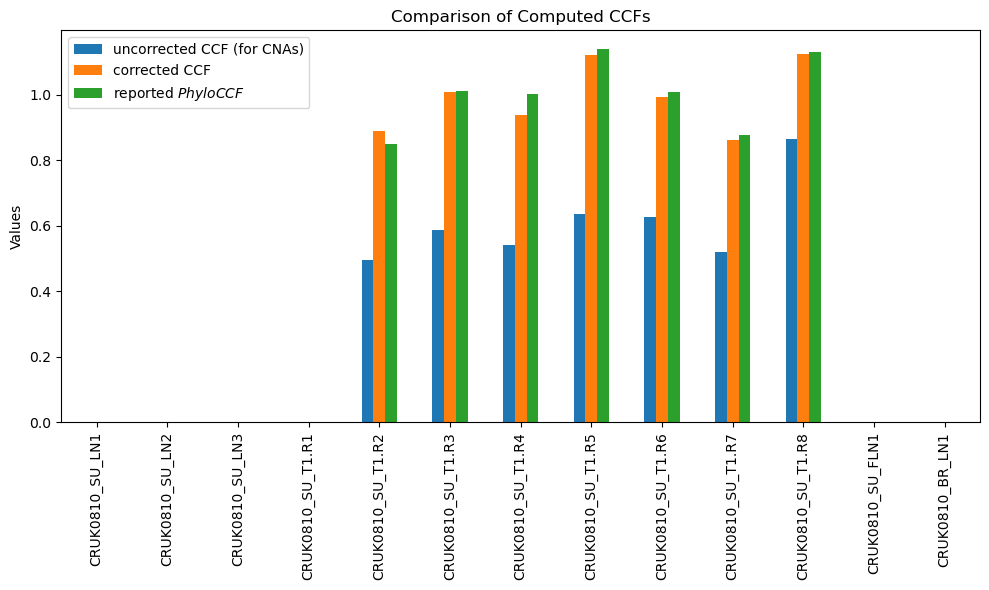

In [187]:
df = pd.DataFrame({
    'uncorrected CCF (for CNAs)': df_vaf.loc[index, samples] * (2/p),
    'corrected CCF': (df_vaf.loc[index, samples]/p) * ((z * p) + (2 * (1 - p))),
    'reported $PhyloCCF$': read_parquet(PARQUET_VALIDATION_CCF).loc[index, samples]
})

df.plot(kind='bar', figsize=(10, 6))
plt.ylabel('Values')
plt.title('Comparison of Computed CCFs')
plt.legend()
plt.tight_layout()
plt.show()

In [264]:
read_parquet(PARQUET_MUTCPN)

,CRUK0810_SU_LN1,CRUK0810_SU_LN2,CRUK0810_SU_LN3,CRUK0810_SU_T1.R1,CRUK0810_SU_T1.R2,CRUK0810_SU_T1.R3,CRUK0810_SU_T1.R4,CRUK0810_SU_T1.R5,CRUK0810_SU_T1.R6,CRUK0810_SU_T1.R7,CRUK0810_SU_T1.R8,CRUK0810_SU_FLN1,CRUK0810_BR_LN1
mutation_id,,,,,,,,,,,,,
CRUK0810:1:2704319:C:T,0.000000,0.000000,0.000000,1.132909,0.910750,0.912282,0.920498,0.828039,1.126033,0.866754,0.937963,0.000000,0.000000
CRUK0810:1:18434754:G:T,0.443363,1.246347,0.583947,0.940704,1.096549,0.852829,1.362411,1.471901,0.860804,0.448401,1.519791,1.521654,2.061586
CRUK0810:1:19501462:G:A,0.000000,0.000000,0.000000,0.000000,0.804914,1.033111,1.050314,1.029143,0.939059,1.026791,1.044856,0.026556,0.000000
CRUK0810:1:20141398:C:A,0.748401,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
CRUK0810:1:23707913:G:A,0.163490,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
CRUK0810:22:23401525:C:A,1.921453,1.982688,2.336978,0.976135,0.825780,1.324386,0.813807,1.076897,1.160266,1.156644,1.044223,1.677206,1.939105
CRUK0810:22:35661321:C:T,0.013933,0.009254,0.000000,0.019274,0.931569,1.064069,0.874744,0.833673,0.951121,0.910812,1.233287,0.019767,0.000000
CRUK0810:22:37420730:C:T,0.827703,0.867539,1.164871,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.013816,0.994531,1.023251


In [219]:
B = (df_total_cpn - (read_parquet(PARQUET_MUTCPN) / read_parquet(PARQUET_VALIDATION_CCF)))

In [220]:
A = (read_parquet(PARQUET_MUTCPN) / read_parquet(PARQUET_VALIDATION_CCF))

In [242]:
A.iloc[:5, :]

,CRUK0810_SU_LN1,CRUK0810_SU_LN2,CRUK0810_SU_LN3,CRUK0810_SU_T1.R1,CRUK0810_SU_T1.R2,CRUK0810_SU_T1.R3,CRUK0810_SU_T1.R4,CRUK0810_SU_T1.R5,CRUK0810_SU_T1.R6,CRUK0810_SU_T1.R7,CRUK0810_SU_T1.R8,CRUK0810_SU_FLN1,CRUK0810_BR_LN1
mutation_id,,,,,,,,,,,,,
CRUK0810:1:2704319:C:T,NaN,NaN,NaN,1.0,1.000000,1.0,1.000000,1.0,1.068646,1.000000,1.000000,NaN,NaN
CRUK0810:1:18434754:G:T,1.0,1.057075,1.0,1.0,1.044127,1.0,1.074299,2.0,1.000000,1.000000,2.000000,1.287451,1.919701
CRUK0810:1:19501462:G:A,NaN,NaN,NaN,NaN,1.000000,1.0,1.074299,1.0,1.000000,1.041367,1.068612,inf,NaN
CRUK0810:1:20141398:C:A,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CRUK0810:1:23707913:G:A,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: ylabel='mutation_id'>

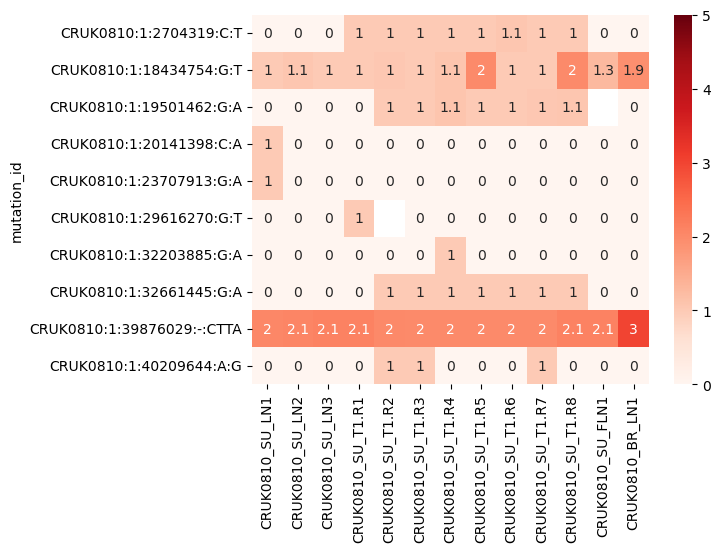

In [261]:
sns.heatmap(A.fillna(0).iloc[:10, :], vmin=0, vmax=5, cmap="Reds", annot=True)

<Axes: ylabel='mutation_id'>

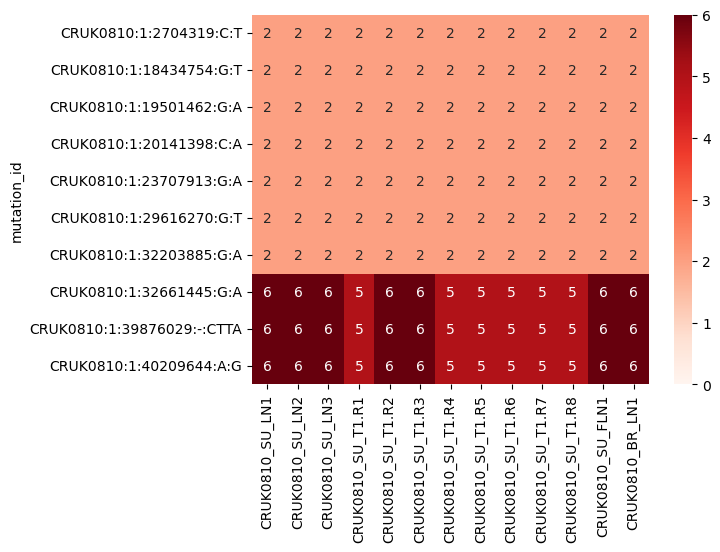

In [260]:
sns.heatmap(df_total_cpn.iloc[:10, :], vmin=0, cmap="Reds",annot=True)

<Axes: ylabel='mutation_id'>

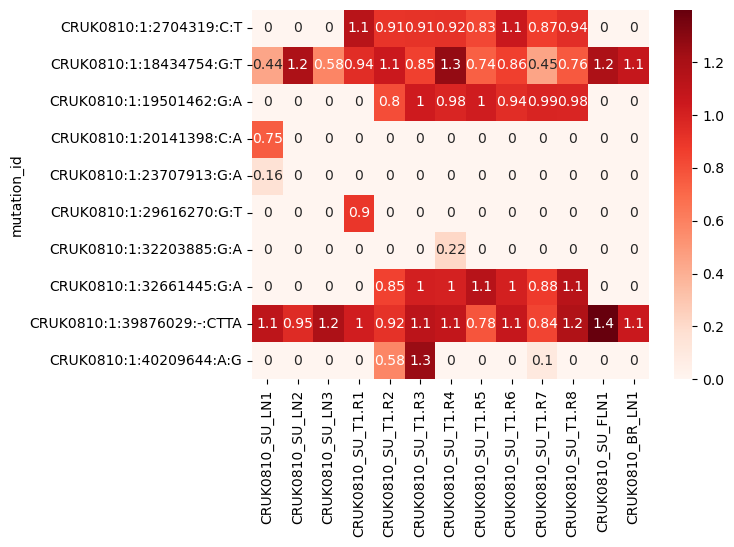

In [259]:
sns.heatmap(read_parquet(PARQUET_VALIDATION_CCF).iloc[:10, :], cmap="Reds",annot=True)

In [269]:
read_parquet(PARQUET_MUTCPN)

,CRUK0810_SU_LN1,CRUK0810_SU_LN2,CRUK0810_SU_LN3,CRUK0810_SU_T1.R1,CRUK0810_SU_T1.R2,CRUK0810_SU_T1.R3,CRUK0810_SU_T1.R4,CRUK0810_SU_T1.R5,CRUK0810_SU_T1.R6,CRUK0810_SU_T1.R7,CRUK0810_SU_T1.R8,CRUK0810_SU_FLN1,CRUK0810_BR_LN1
mutation_id,,,,,,,,,,,,,
CRUK0810:1:2704319:C:T,0.000000,0.000000,0.000000,1.132909,0.910750,0.912282,0.920498,0.828039,1.126033,0.866754,0.937963,0.000000,0.000000
CRUK0810:1:18434754:G:T,0.443363,1.246347,0.583947,0.940704,1.096549,0.852829,1.362411,1.471901,0.860804,0.448401,1.519791,1.521654,2.061586
CRUK0810:1:19501462:G:A,0.000000,0.000000,0.000000,0.000000,0.804914,1.033111,1.050314,1.029143,0.939059,1.026791,1.044856,0.026556,0.000000
CRUK0810:1:20141398:C:A,0.748401,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
CRUK0810:1:23707913:G:A,0.163490,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
CRUK0810:22:23401525:C:A,1.921453,1.982688,2.336978,0.976135,0.825780,1.324386,0.813807,1.076897,1.160266,1.156644,1.044223,1.677206,1.939105
CRUK0810:22:35661321:C:T,0.013933,0.009254,0.000000,0.019274,0.931569,1.064069,0.874744,0.833673,0.951121,0.910812,1.233287,0.019767,0.000000
CRUK0810:22:37420730:C:T,0.827703,0.867539,1.164871,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.013816,0.994531,1.023251


In [271]:
read_parquet(PARQUET_VALIDATION_CCF)

,CRUK0810_SU_LN1,CRUK0810_SU_LN2,CRUK0810_SU_LN3,CRUK0810_SU_T1.R1,CRUK0810_SU_T1.R2,CRUK0810_SU_T1.R3,CRUK0810_SU_T1.R4,CRUK0810_SU_T1.R5,CRUK0810_SU_T1.R6,CRUK0810_SU_T1.R7,CRUK0810_SU_T1.R8,CRUK0810_SU_FLN1,CRUK0810_BR_LN1
mutation_id,,,,,,,,,,,,,
CRUK0810:1:2704319:C:T,0.000000,0.000000,0.000000,1.132909,0.910750,0.912282,0.920498,0.828039,1.053700,0.866754,0.937963,0.000000,0.000000
CRUK0810:1:18434754:G:T,0.443363,1.179053,0.583947,0.940704,1.050207,0.852829,1.268185,0.735950,0.860804,0.448401,0.759895,1.181912,1.073910
CRUK0810:1:19501462:G:A,0.000000,0.000000,0.000000,0.000000,0.804914,1.033111,0.977673,1.029143,0.939059,0.986004,0.977769,0.000000,0.000000
CRUK0810:1:20141398:C:A,0.748401,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
CRUK0810:1:23707913:G:A,0.163490,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
CRUK0810:22:23401525:C:A,1.009896,0.991344,1.210049,0.976135,0.825780,1.294463,0.813807,1.022310,1.115739,1.109300,1.044223,0.870191,0.982204
CRUK0810:22:35661321:C:T,0.000000,0.000000,0.000000,0.000000,0.931569,1.040027,0.874744,0.833673,0.951121,0.910812,1.167380,0.000000,0.000000
CRUK0810:22:37420730:C:T,0.827703,0.867539,1.116931,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.994531,1.023251


In [268]:
A

,CRUK0810_SU_LN1,CRUK0810_SU_LN2,CRUK0810_SU_LN3,CRUK0810_SU_T1.R1,CRUK0810_SU_T1.R2,CRUK0810_SU_T1.R3,CRUK0810_SU_T1.R4,CRUK0810_SU_T1.R5,CRUK0810_SU_T1.R6,CRUK0810_SU_T1.R7,CRUK0810_SU_T1.R8,CRUK0810_SU_FLN1,CRUK0810_BR_LN1
mutation_id,,,,,,,,,,,,,
CRUK0810:1:2704319:C:T,NaN,NaN,NaN,1.0,1.000000,1.000000,1.000000,1.000000,1.068646,1.000000,1.000000,NaN,NaN
CRUK0810:1:18434754:G:T,1.000000,1.057075,1.000000,1.0,1.044127,1.000000,1.074299,2.000000,1.000000,1.000000,2.000000,1.287451,1.919701
CRUK0810:1:19501462:G:A,NaN,NaN,NaN,NaN,1.000000,1.000000,1.074299,1.000000,1.000000,1.041367,1.068612,inf,NaN
CRUK0810:1:20141398:C:A,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CRUK0810:1:23707913:G:A,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
CRUK0810:22:23401525:C:A,1.902624,2.000000,1.931308,1.0,1.000000,1.023116,1.000000,1.053396,1.039908,1.042680,1.000000,1.927401,1.974240
CRUK0810:22:35661321:C:T,inf,inf,NaN,inf,1.000000,1.023116,1.000000,1.000000,1.000000,1.000000,1.056457,inf,NaN
CRUK0810:22:37420730:C:T,1.000000,1.000000,1.042921,NaN,NaN,NaN,NaN,NaN,NaN,NaN,inf,1.000000,1.000000


In [267]:
df_total_cpn

,CRUK0810_SU_LN1,CRUK0810_SU_LN2,CRUK0810_SU_LN3,CRUK0810_SU_T1.R1,CRUK0810_SU_T1.R2,CRUK0810_SU_T1.R3,CRUK0810_SU_T1.R4,CRUK0810_SU_T1.R5,CRUK0810_SU_T1.R6,CRUK0810_SU_T1.R7,CRUK0810_SU_T1.R8,CRUK0810_SU_FLN1,CRUK0810_BR_LN1
mutation_id,,,,,,,,,,,,,
CRUK0810:1:2704319:C:T,2,2,2,2,2,2,2,2,2,2,2,2,2
CRUK0810:1:18434754:G:T,2,2,2,2,2,2,2,2,2,2,2,2,2
CRUK0810:1:19501462:G:A,2,2,2,2,2,2,2,2,2,2,2,2,2
CRUK0810:1:20141398:C:A,2,2,2,2,2,2,2,2,2,2,2,2,2
CRUK0810:1:23707913:G:A,2,2,2,2,2,2,2,2,2,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
CRUK0810:22:23401525:C:A,3,3,3,3,3,3,3,3,3,3,3,3,3
CRUK0810:22:35661321:C:T,3,3,3,3,3,3,3,3,3,3,3,3,3
CRUK0810:22:37420730:C:T,3,3,3,3,3,3,3,3,3,3,3,3,3


In [272]:
es = (A / df_total_cpn).fillna(0)

In [298]:
res = es.where(np.isfinite(es), 0)

In [318]:
res.where(res<1, 1)

,CRUK0810_SU_LN1,CRUK0810_SU_LN2,CRUK0810_SU_LN3,CRUK0810_SU_T1.R1,CRUK0810_SU_T1.R2,CRUK0810_SU_T1.R3,CRUK0810_SU_T1.R4,CRUK0810_SU_T1.R5,CRUK0810_SU_T1.R6,CRUK0810_SU_T1.R7,CRUK0810_SU_T1.R8,CRUK0810_SU_FLN1,CRUK0810_BR_LN1
mutation_id,,,,,,,,,,,,,
CRUK0810:1:2704319:C:T,0.000000,0.000000,0.000000,0.500000,0.500000,0.500000,0.500000,0.500000,0.534323,0.500000,0.500000,0.000000,0.000000
CRUK0810:1:18434754:G:T,0.500000,0.528537,0.500000,0.500000,0.522063,0.500000,0.537150,1.000000,0.500000,0.500000,1.000000,0.643725,0.959851
CRUK0810:1:19501462:G:A,0.000000,0.000000,0.000000,0.000000,0.500000,0.500000,0.537150,0.500000,0.500000,0.520683,0.534306,0.000000,0.000000
CRUK0810:1:20141398:C:A,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
CRUK0810:1:23707913:G:A,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
CRUK0810:22:23401525:C:A,0.634208,0.666667,0.643769,0.333333,0.333333,0.341039,0.333333,0.351132,0.346636,0.347560,0.333333,0.642467,0.658080
CRUK0810:22:35661321:C:T,0.000000,0.000000,0.000000,0.000000,0.333333,0.341039,0.333333,0.333333,0.333333,0.333333,0.352152,0.000000,0.000000
CRUK0810:22:37420730:C:T,0.333333,0.333333,0.347640,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.333333,0.333333


In [ ]:
df_var_counts

,CRUK0810_SU_LN1,CRUK0810_SU_LN2,CRUK0810_SU_LN3,CRUK0810_SU_T1.R1,CRUK0810_SU_T1.R2,CRUK0810_SU_T1.R3,CRUK0810_SU_T1.R4,CRUK0810_SU_T1.R5,CRUK0810_SU_T1.R6,CRUK0810_SU_T1.R7,CRUK0810_SU_T1.R8,CRUK0810_SU_FLN1,CRUK0810_BR_LN1
mutation_id,,,,,,,,,,,,,
CRUK0810:1:2704319:C:T,0,0,0,19,20,15,22,22,29,19,14,0,0
CRUK0810:1:18434754:G:T,4,16,2,6,10,5,17,19,9,4,8,9,13
CRUK0810:1:19501462:G:A,0,0,0,0,30,29,31,35,44,42,22,1,0
CRUK0810:1:20141398:C:A,42,0,0,0,0,0,0,0,0,0,0,0,0
CRUK0810:1:23707913:G:A,19,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
CRUK0810:22:23401525:C:A,35,54,14,10,19,17,14,21,26,25,14,20,22
CRUK0810:22:35661321:C:T,1,1,0,1,73,60,70,71,92,82,61,2,0
CRUK0810:22:37420730:C:T,98,141,46,0,0,0,0,0,0,0,1,184,77


In [279]:
df_tot_counts

,CRUK0810_SU_LN1,CRUK0810_SU_LN2,CRUK0810_SU_LN3,CRUK0810_SU_T1.R1,CRUK0810_SU_T1.R2,CRUK0810_SU_T1.R3,CRUK0810_SU_T1.R4,CRUK0810_SU_T1.R5,CRUK0810_SU_T1.R6,CRUK0810_SU_T1.R7,CRUK0810_SU_T1.R8,CRUK0810_SU_FLN1,CRUK0810_BR_LN1
mutation_id,,,,,,,,,,,,,
CRUK0810:1:2704319:C:T,121,108,114,141,115,95,104,106,134,105,150,128,111
CRUK0810:1:18434754:G:T,59,45,53,52,46,33,52,52,54,41,53,30,48
CRUK0810:1:19501462:G:A,227,186,179,210,188,158,123,137,242,188,212,191,151
CRUK0810:1:20141398:C:A,367,314,322,363,291,236,279,286,330,291,385,404,312
CRUK0810:1:23707913:G:A,760,647,691,684,602,585,560,556,824,638,803,515,664
...,...,...,...,...,...,...,...,...,...,...,...,...,...
CRUK0810:22:23401525:C:A,134,123,98,93,138,84,89,98,139,121,148,66,98
CRUK0810:22:35661321:C:T,528,488,460,471,470,369,414,429,600,504,546,560,443
CRUK0810:22:37420730:C:T,871,734,646,678,719,595,653,676,836,729,799,1024,651


In [319]:
column_names = df_var_counts.columns

with open("/Users/wuchh/Downloads/test_cn-PairTree-CRUK0810.ssm", "w") as f:

    f.write("id\tname\tvar_reads\ttotal_reads\tvar_read_prob\n")

    for i in range(len(df_var_counts)):

        mut_name = df_var_counts.iloc[i].name
        row_values = [f"s{i}", mut_name.replace(":", "_"), 
                    ','.join(map(str, df_var_counts.loc[mut_name, column_names])),
                    ','.join(map(str, df_tot_counts.loc[mut_name, column_names])),
                    ','.join(map(str, res.where(res<1, 1).loc[mut_name, column_names]))]

        stringOut = "\t".join(row_values) + "\n"
        f.write(stringOut)
    # break

In [308]:
print(stringOut)

s517	CRUK0810_22_50617772_G_A	13,21,9,0,0,0,0,0,0,0,0,21,13	157,131,114,141,119,98,125,130,144,132,154,96,127	0.3333333333333333,0.3333333333333333,0.3333333333333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.3333333333333333,0.3333333333333333



In [ ]:
','.join(map(str, df_var_counts.loc[mut_name, column_names])),
','.join(map(str, df_tot_counts.loc[mut_name, column_names])),
','.join(map(str, res.loc[mut_name, column_names]))

'0,0,0,19,20,15,22,22,29,19,14,0,0'

In [297]:
','.join(map(str, df_tot_counts.loc[mut_name, column_names]))

'121,108,114,141,115,95,104,106,134,105,150,128,111'

In [299]:
','.join(map(str, res.loc[mut_name, column_names]))

'0.0,0.0,0.0,0.5,0.5,0.5,0.5,0.5,0.5343230631336072,0.5,0.5,0.0,0.0'

In [320]:
import json

In [321]:
with open("/Users/wuchh/Local/repositories/tree-alignment/workspace/results/trees/pairtree/CRUK0810/CRUK0810.json") as f:
    x = json.load(f)

In [324]:
len(x["clusters"])

27

In [214]:
read_parquet(PARQUET_VALIDATION_CCF)

,CRUK0810_SU_LN1,CRUK0810_SU_LN2,CRUK0810_SU_LN3,CRUK0810_SU_T1.R1,CRUK0810_SU_T1.R2,CRUK0810_SU_T1.R3,CRUK0810_SU_T1.R4,CRUK0810_SU_T1.R5,CRUK0810_SU_T1.R6,CRUK0810_SU_T1.R7,CRUK0810_SU_T1.R8,CRUK0810_SU_FLN1,CRUK0810_BR_LN1
mutation_id,,,,,,,,,,,,,
CRUK0810:1:2704319:C:T,0.000000,0.000000,0.000000,1.132909,0.910750,0.912282,0.920498,0.828039,1.053700,0.866754,0.937963,0.000000,0.000000
CRUK0810:1:18434754:G:T,0.443363,1.179053,0.583947,0.940704,1.050207,0.852829,1.268185,0.735950,0.860804,0.448401,0.759895,1.181912,1.073910
CRUK0810:1:19501462:G:A,0.000000,0.000000,0.000000,0.000000,0.804914,1.033111,0.977673,1.029143,0.939059,0.986004,0.977769,0.000000,0.000000
CRUK0810:1:20141398:C:A,0.748401,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
CRUK0810:1:23707913:G:A,0.163490,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
CRUK0810:22:23401525:C:A,1.009896,0.991344,1.210049,0.976135,0.825780,1.294463,0.813807,1.022310,1.115739,1.109300,1.044223,0.870191,0.982204
CRUK0810:22:35661321:C:T,0.000000,0.000000,0.000000,0.000000,0.931569,1.040027,0.874744,0.833673,0.951121,0.910812,1.167380,0.000000,0.000000
CRUK0810:22:37420730:C:T,0.827703,0.867539,1.116931,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.994531,1.023251


In [198]:
read_parquet(PARQUET_MUTCPN)

,CRUK0810_SU_LN1,CRUK0810_SU_LN2,CRUK0810_SU_LN3,CRUK0810_SU_T1.R1,CRUK0810_SU_T1.R2,CRUK0810_SU_T1.R3,CRUK0810_SU_T1.R4,CRUK0810_SU_T1.R5,CRUK0810_SU_T1.R6,CRUK0810_SU_T1.R7,CRUK0810_SU_T1.R8,CRUK0810_SU_FLN1,CRUK0810_BR_LN1
mutation_id,,,,,,,,,,,,,
CRUK0810:1:2704319:C:T,0.000000,0.000000,0.000000,1.132909,0.910750,0.912282,0.920498,0.828039,1.126033,0.866754,0.937963,0.000000,0.000000
CRUK0810:1:18434754:G:T,0.443363,1.246347,0.583947,0.940704,1.096549,0.852829,1.362411,1.471901,0.860804,0.448401,1.519791,1.521654,2.061586
CRUK0810:1:19501462:G:A,0.000000,0.000000,0.000000,0.000000,0.804914,1.033111,1.050314,1.029143,0.939059,1.026791,1.044856,0.026556,0.000000
CRUK0810:1:20141398:C:A,0.748401,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
CRUK0810:1:23707913:G:A,0.163490,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
CRUK0810:22:23401525:C:A,1.921453,1.982688,2.336978,0.976135,0.825780,1.324386,0.813807,1.076897,1.160266,1.156644,1.044223,1.677206,1.939105
CRUK0810:22:35661321:C:T,0.013933,0.009254,0.000000,0.019274,0.931569,1.064069,0.874744,0.833673,0.951121,0.910812,1.233287,0.019767,0.000000
CRUK0810:22:37420730:C:T,0.827703,0.867539,1.164871,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.013816,0.994531,1.023251


In [199]:
read_parquet(PARQUET_VALIDATION_CCF)

,CRUK0810_SU_LN1,CRUK0810_SU_LN2,CRUK0810_SU_LN3,CRUK0810_SU_T1.R1,CRUK0810_SU_T1.R2,CRUK0810_SU_T1.R3,CRUK0810_SU_T1.R4,CRUK0810_SU_T1.R5,CRUK0810_SU_T1.R6,CRUK0810_SU_T1.R7,CRUK0810_SU_T1.R8,CRUK0810_SU_FLN1,CRUK0810_BR_LN1
mutation_id,,,,,,,,,,,,,
CRUK0810:1:2704319:C:T,0.000000,0.000000,0.000000,1.132909,0.910750,0.912282,0.920498,0.828039,1.053700,0.866754,0.937963,0.000000,0.000000
CRUK0810:1:18434754:G:T,0.443363,1.179053,0.583947,0.940704,1.050207,0.852829,1.268185,0.735950,0.860804,0.448401,0.759895,1.181912,1.073910
CRUK0810:1:19501462:G:A,0.000000,0.000000,0.000000,0.000000,0.804914,1.033111,0.977673,1.029143,0.939059,0.986004,0.977769,0.000000,0.000000
CRUK0810:1:20141398:C:A,0.748401,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
CRUK0810:1:23707913:G:A,0.163490,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
CRUK0810:22:23401525:C:A,1.009896,0.991344,1.210049,0.976135,0.825780,1.294463,0.813807,1.022310,1.115739,1.109300,1.044223,0.870191,0.982204
CRUK0810:22:35661321:C:T,0.000000,0.000000,0.000000,0.000000,0.931569,1.040027,0.874744,0.833673,0.951121,0.910812,1.167380,0.000000,0.000000
CRUK0810:22:37420730:C:T,0.827703,0.867539,1.116931,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.994531,1.023251


In [203]:
mutational_clusters = pd.read_csv("/Users/wuchh/Downloads/CRUK0810_pyclone_cluster.csv", index_col=0)

In [204]:
mutational_clusters

,PycloneCluster
CRUK0810:1:2704319:C:T,4
CRUK0810:1:18434754:G:T,1
CRUK0810:1:19501462:G:A,6
CRUK0810:1:20141398:C:A,20
CRUK0810:1:23707913:G:A,21
...,...
CRUK0810:22:23401525:C:A,1
CRUK0810:22:35661321:C:T,6
CRUK0810:22:37420730:C:T,2
CRUK0810:22:37966167:G:A,28


/var/folders/_k/0wd_frsd3dg1x487y924q979_83jn9/T/ipykernel_6598/2837627888.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 1])


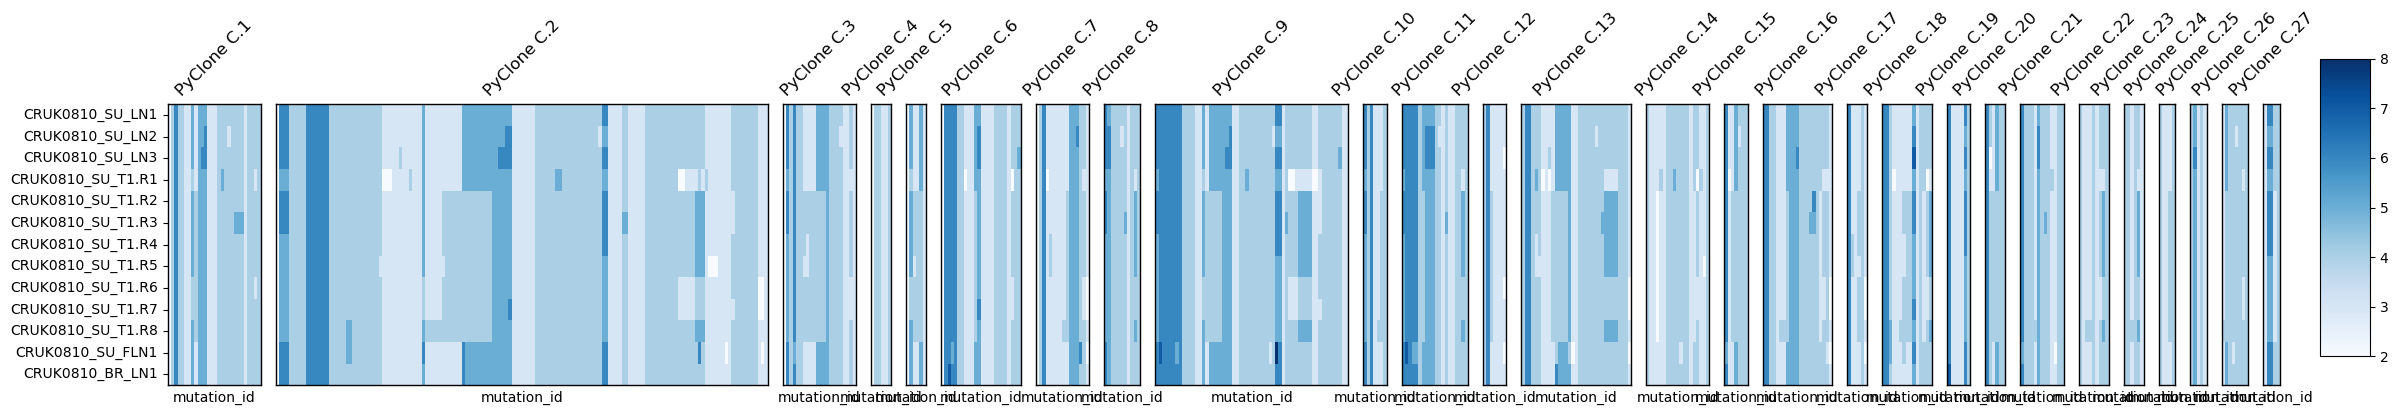

In [208]:
df = df_total_cpn
groups = mutational_clusters["PycloneCluster"].tolist()
split_dfs = [group for _, group in df.groupby(groups, sort=False)]
vmin = df.min().min()
vmax = df.max().max()
width_ratios = [len(sub_df) for sub_df in split_dfs]

fig, axes = plt.subplots(1, len(split_dfs), figsize=(25, 4.25),
                         gridspec_kw={'width_ratios': width_ratios})

if len(split_dfs) == 1:
    axes = [axes]

for i, (ax, sub_df) in enumerate(zip(axes, split_dfs)):
    sns.heatmap(sub_df.T, ax=ax, cmap='Blues',
                vmin=vmin, vmax=vmax,
                cbar=False,
                yticklabels=(i == 0),
                xticklabels=False,
                linewidths=0,
                linecolor='none')
    ax.set_title(f'PyClone C.{i+1}', rotation=45, ha='center')
    if i == 0:
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.)
        spine.set_visible(True)

fig.subplots_adjust(right=0.92)
cbar_ax = fig.add_axes([0.93, 0.15, 0.02, 0.7])
sm = plt.cm.ScalarMappable(cmap='Blues', norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax)

plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.show()

In [213]:
mutational_clusters["PycloneCluster"].unique()

array([ 4,  1,  6, 20, 21,  5, 10, 13,  2, 17,  8, 16,  3,  9, 18,  7, 22,
       11, 19, 23, 12, 14, 24, 26, 28, 15, 27])

In [327]:
pd.read_parquet('/Users/wuchh/Downloads/totalReadsParquetTracerx/CRUK0810.totalReads.parquet')

,CRUK0810_SU_LN1_cov,CRUK0810_SU_LN2_cov,CRUK0810_SU_LN3_cov,CRUK0810_SU_T1.R1_cov,CRUK0810_SU_T1.R2_cov,CRUK0810_SU_T1.R3_cov,CRUK0810_SU_T1.R4_cov,CRUK0810_SU_T1.R5_cov,CRUK0810_SU_T1.R6_cov,CRUK0810_SU_T1.R7_cov,CRUK0810_SU_T1.R8_cov,CRUK0810_SU_FLN1_cov,CRUK0810_BR_LN1_cov
0,121,108,114,141,115,95,104,106,134,105,150,128,111
1,59,45,53,52,46,33,52,52,54,41,53,30,48
2,227,186,179,210,188,158,123,137,242,188,212,191,151
3,367,314,322,363,291,236,279,286,330,291,385,404,312
4,760,647,691,684,602,585,560,556,824,638,803,515,664
...,...,...,...,...,...,...,...,...,...,...,...,...,...
513,134,123,98,93,138,84,89,98,139,121,148,66,98
514,528,488,460,471,470,369,414,429,600,504,546,560,443
515,871,734,646,678,719,595,653,676,836,729,799,1024,651
516,170,155,119,131,131,76,137,120,184,149,147,84,134
